<a href="https://colab.research.google.com/github/lilianabs/kaggle-tools/blob/main/Data_leakage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🧠 1. What is leakage (simple + precise)

Data leakage = using information at training time that would NOT be available at prediction time

It creates:

- artificially high performance
- misleading conclusions
- broken real-world systems

🔥 2. The intuition

Ask this for every feature:

“At the moment I need to make a prediction… could I realistically know this value?”

If the answer is no → leakage

🚨 3. Common types of leakage

1. Target leakage (most dangerous)

Feature directly encodes the target.

Example:

- Predict: “Will customer churn?”
- Feature: “account_closed_date”

👉 That’s basically the answer.

2. Post-event leakage

Feature is created after the outcome.

Example:

- Predict: loan default
- Feature: “number_of_missed_payments”

👉 Only known after default behavior starts

3. Train-test contamination

Information from test set leaks into training.

Example:

- Scaling using full dataset
- Encoding using full dataset

4. Aggregation leakage

Using future data in aggregates.

Example:

- “average user spend” computed over entire dataset
- includes future transactions

5. ID / proxy leakage

Feature indirectly identifies the target.

Example:

- user_id that correlates with outcome
- order_id encoding time or grouping

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
n = 2000

# Target
y = np.random.binomial(1, 0.5, n)

# ===== NUMERICAL FEATURES =====

# Strong signal
num_strong = np.where(y == 1,
                      np.random.normal(2, 1, n),
                      np.random.normal(-2, 1, n))

# Weak signal
num_weak = np.where(y == 1,
                    np.random.normal(0.5, 1.5, n),
                    np.random.normal(0, 1.5, n))

# Noise
num_noise = np.random.normal(0, 1, n)

# Correlated features
num_corr1 = num_strong + np.random.normal(0, 0.2, n)
num_corr2 = num_strong * 0.8 + np.random.normal(0, 0.3, n)

# ===== CATEGORICAL FEATURES =====

# Strong categorical signal
cat_strong = np.where(y == 1,
                      np.random.choice(["A", "B"], n, p=[0.2, 0.8]),
                      np.random.choice(["A", "B"], n, p=[0.8, 0.2]))

# Weak categorical signal
cat_weak = np.where(y == 1,
                    np.random.choice(["X", "Y"], n, p=[0.45, 0.55]),
                    np.random.choice(["X", "Y"], n, p=[0.55, 0.45]))

# Noise categorical
cat_noise = np.random.choice(["K", "L", "M"], n)

# High-cardinality (dangerous)
cat_high_card = ["id_" + str(i) for i in range(n)]

# Rare category trap
cat_rare = np.random.choice(["R1", "R2", "R3"], n, p=[0.49, 0.49, 0.02])
cat_rare[y == 1][:10] = "R3"  # inject fake strong signal

df = pd.DataFrame({
    "target": y,
    "num_strong": num_strong,
    "num_weak": num_weak,
    "num_noise": num_noise,
    "num_corr1": num_corr1,
    "num_corr2": num_corr2,
    "cat_strong": cat_strong,
    "cat_weak": cat_weak,
    "cat_noise": cat_noise,
    "cat_high_card": cat_high_card,
    "cat_rare": cat_rare
})


In [2]:
# Perfect leakage
df["leak_perfect"] = df["target"]

# Noisy leakage
df["leak_noisy"] = df["target"] + np.random.normal(0, 0.1, len(df))

In [3]:
df.head()

,target,num_strong,num_weak,num_noise,num_corr1,num_corr2,cat_strong,cat_weak,cat_noise,cat_high_card,cat_rare,leak_perfect,leak_noisy
0,0,-1.653290,-2.288358,0.555826,-1.418088,-1.480033,A,X,L,id_0,R1,0,0.061976
1,1,1.173120,1.458016,-0.226527,1.400073,1.166853,B,Y,K,id_1,R1,1,1.011729
2,1,1.773521,0.404640,-0.430428,1.859550,0.966992,B,X,L,id_2,R1,1,0.960997
3,1,2.367366,-1.676392,2.008473,2.469073,1.768566,B,Y,L,id_3,R1,1,1.110613
4,0,-1.359457,1.970673,-1.472354,-1.274931,-1.618883,A,X,L,id_4,R2,0,-0.171532


## Train model

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

X = df.drop(columns=["target"])
y = df["target"]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(include="number").columns

cat_cols = cat_cols.drop(["cat_high_card"])
#num_cols = num_cols.drop(["num_corr2", "num_corr1"])

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, preds)

np.float64(1.0)

👉 You’ll likely see:

ROC-AUC ≈ 0.99–1.0
🚨 This is your red flag

“My model is too good to be true”

🔍 5. How to detect leakage (systematic approach)

1. Suspiciously high performance

Heuristics:

- AUC > 0.95 (for most real problems) → investigate
- Huge jump after adding one feature

In [9]:
model.named_steps["clf"].feature_importances_

array([2.13921864e-02, 1.69040562e-02, 6.99507773e-05, 2.23793890e-04,
       8.08345970e-05, 3.82069692e-05, 9.11675554e-05, 5.22279013e-05,
       6.44827876e-05, 4.32436357e-05, 1.51414744e-01, 1.42047957e-03,
       6.46016598e-04, 1.06834415e-01, 1.18015613e-01, 3.16212221e-01,
       2.66496360e-01])

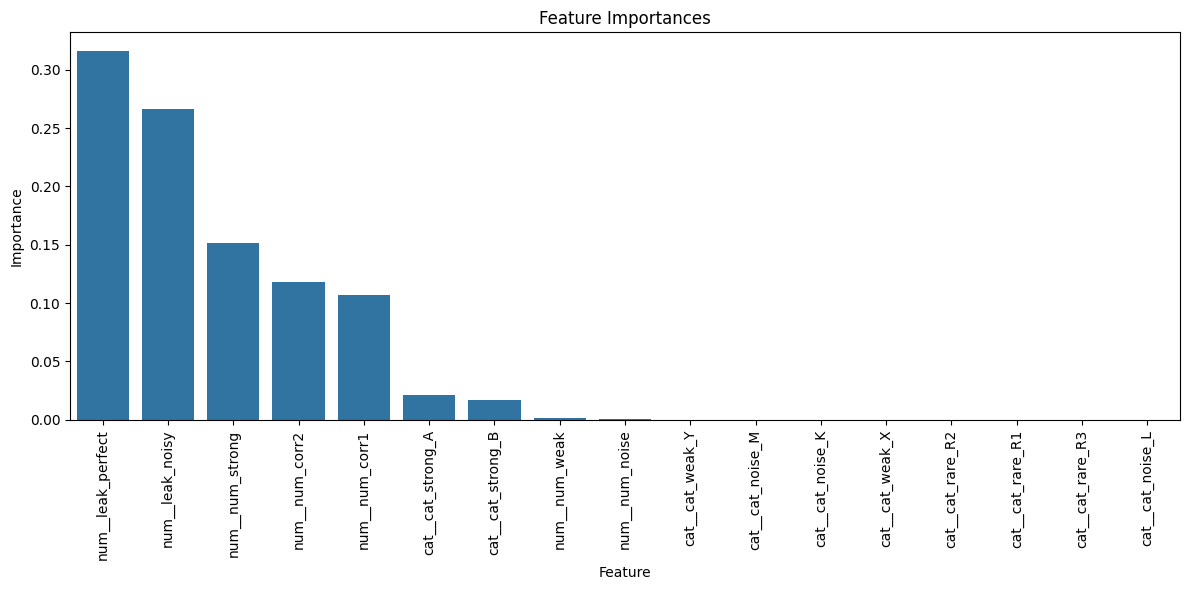

In [10]:
importances = model.named_steps["clf"].feature_importances_
feature_names = model.named_steps['prep'].get_feature_names_out()
feature_importances = pd.Series(importances, index=feature_names)

# Sort feature importances for better visualization
sorted_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_importances.index, y=sorted_importances.values)
plt.xticks(rotation=90)
plt.title('Feature Importances')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

👉 Leakage features dominate massively

In [11]:
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

for col in df.columns:
    if col == "target":
        continue

    X = pd.get_dummies(df[[col]])
    model = LogisticRegression(max_iter=1000)
    model.fit(X, df["target"])

    preds = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(df["target"], preds)

    print(col, round(auc, 3))

num_strong 0.998
num_weak 0.576
num_noise 0.502
num_corr1 0.997
num_corr2 0.996
cat_strong 0.791
cat_weak 0.547
cat_noise 0.516
cat_high_card 1.0
cat_rare 0.524
leak_perfect 1.0
leak_noisy 1.0


👉 If you see:

- A single feature with AUC ~ 0.98+

💥 That’s almost certainly leakage

4. Time-based sanity check

Ask:

- Does this feature depend on future information?

Example:

- “total purchases” → depends on when measured

5. Domain reasoning (most important)

No code replaces this:

- “How is this feature generated in the real world?”

⚠️ 6. Subtle leakage (this is what gets people)

Case: Data preprocessing

❌ Wrong:

scaler.fit(X)  # before split

✅ Correct:

scaler.fit(X_train)

Case: Target encoding

If done incorrectly:

- category → average target
- computed on full dataset

👉 leaks target information

Case: Cross-validation mistakes
- Not grouping by user/session
- Same entity appears in train and test

🧠 7. Mental checklist (use this always)

For every feature:

Was this available at prediction time?
1. Could it be derived from the target?
1. Does it use future data?
1. Does it uniquely identify rows/groups?
1. Does it make the model “too perfect”?

🎯 8. What to do when you find leakage
- Drop the feature immediately
- Rebuild pipeline correctly
- Re-evaluate performance (expect drop)

👉 Lower but realistic performance is GOOD

🔥 9. Real-world intuition

Good model:

- AUC: 0.70–0.85
- Stable across splits

Leaky model:

- AUC: 0.98
- Fails in production